In [ ]:
# Libraries 
import numpy as np

# Data Preprocessing

## SmartSeq


#### SmartSeq MCF7 Unfiltered

In [316]:
#Initial dataframe exploration
df_SSMCF7 = pd.read_csv("SmartSeq/MCF7/MCF7_SmartS_Unfiltered_Data.txt",delimiter=r"\ ",engine='python',index_col=0)
print("Dataframe dimensions:", np.shape(df_SSMCF7))
df_SSMCF7.head(5)

Dataframe dimensions: (22934, 383)


,"""output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A3_Norm_S3_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A4_Norm_S4_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A5_Norm_S5_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A6_Norm_S6_Aligned.sortedByCoord.out.bam""","""output.STAR.1_A7_Hypo_S25_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.4_H14_Hypo_S383_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H1_Norm_S355_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H2_Norm_S356_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H3_Norm_S357_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H4_Norm_S358_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam"""
"""WASH7P""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
"""MIR6859-1""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""WASH9P""",1,0,0,0,0,1,10,1,0,0,...,1,1,0,0,0,0,1,1,4,5
"""OR4F29""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
"""MTND1P23""",0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


The next crucial step in our analysis is to check for duplicates. They could result in double counting and skew the databaes in ways that do not accurately represent the true nature of the data. We check for duplicate cell names and gene names which would suggest an initial issue with our dataset that we need to fix. Also we check for duplicatate cell and gene profiles. We see that there are no two duplicate cell profiles so there are no two cells that have the same expression of each gene. We however see that there are duplicate gene expressions, so there are genes that have the same expression values across the cells. These genes are most likely 'maintenance' genes and will not provide any variance that could be used in models but in this case keeping them will not harm our analysis as is is representative of the true biological nature of the cells. If the duplicates however are the exact same gene but with different name, bias might be created if we decide to keep all instances of them. Still, such removal should be properly documented. 

In [318]:
# CHECKING FOR DUPLICATES

# Check for duplicate cell names
duplicates_in_cells = df_SSMCF7.index.duplicated().sum()
print(f"Duplicate cell names: {duplicates_in_cells}")

# Check for duplicate gene names
duplicates_in_genes = df_SSMCF7.columns.duplicated().sum()
print(f"Duplicate gene names: {duplicates_in_genes}")

# Check for duplicate cell profiles
duplicate_gene_profiles = df_SSMCF7.T.duplicated().sum()
print("Duplicate gene profiles:", duplicate_gene_profiles)

# Check for duplicate gene profiles
duplicate_gene_profiles = df_SSMCF7.duplicated().sum()
print("Duplicate gene profiles:", duplicate_gene_profiles)

#Check for missing values
has_nulls = df_SSMCF7.T.isnull().values.any()
print(f"Missing values:", has_nulls)

Duplicate cell names: 0
Duplicate gene names: 0
Duplicate gene profiles: 0
Duplicate gene profiles: 29
Missing values: False


##### Quality Control

Next, we can perform some quality control on the cells. What we can do is to check the total read counts of the genes for each cell and discard cells under a certain thereshold. According to bioconductor.org a sutable threshold would be 100 000 total reads per cell. Any lower than that and we risk including damaged cells in our database and analysis which could lead to additional noise, obscuring the actual dependencies we are trying to find. 

In [321]:
total_reads_per_cell = df_SSMCF7.sum(axis=0)

low_quality_cells = (total_reads_per_cell < 100000).sum()

print(f"Number of cells with total reads < 100,000: {low_quality_cells}")

Number of cells with total reads < 100,000: 44


Additionally, we can also remove cells that express less than a certian amount of genes. as again this could indicate that the cell is damaged. According to bioconductor.org a suitable cut-off would be around 5000. 

In [323]:
# Set your threshold
N = 5000  # example threshold

# Count how many genes are expressed (non-zero) in each cell
genes_per_cell = (df_SSMCF7 > 0).sum(axis=0)

# Count how many cells have fewer than N expressed genes
low_gene_cells = (genes_per_cell < N).sum()

print(f"Number of cells with fewer than {N} genes expressed: {low_gene_cells}")

Number of cells with fewer than 5000 genes expressed: 33


Lastly we look at the cells with high mitochondrial percentage. Again from the same source we filter out cells with mitochondrial percentage of over 10% as they are likely to be damaged. (i.e. cells in which over 10% of the reads come from mitochondrial genes are dicarded)

In [325]:
mito_genes = df_SSMCF7.index.str.replace('"', '').str.upper().str.startswith("MT")
mito_reads = df_SSMCF7.loc[mito_genes].sum(axis=0)
total_reads = df_SSMCF7.sum(axis=0)

mito_percent = mito_reads / total_reads * 100

threshold = 5

num_high_mito_cells = (mito_percent >= threshold).sum()
print(f"Number of cells with > {threshold}% mitochondrial reads: {num_high_mito_cells}")

Number of cells with > 5% mitochondrial reads: 12


Now we remove the cells that are likely to be damaged. 

In [327]:
# Build a boolean mask: keep only cells that meet both thresholds
high_quality_cells = (total_reads_per_cell >= 100000) & (genes_per_cell >= 5000) & (mito_percent < 5)

# Filter the DataFrame to keep only those cells (columns)
df_filtered_SSMCF7 = df_SSMCF7.loc[:, high_quality_cells]

print(f"Original number of cells: {df_SSMCF7.shape[1]}")
print(f"Number of cells kept after filtering: {df_filtered_SSMCF7.shape[1]}")

Original number of cells: 383
Number of cells kept after filtering: 328


What we do below is to double check that our thresholds are reasonable. For that we will make some plots that will help is with visualizing the numbers. 

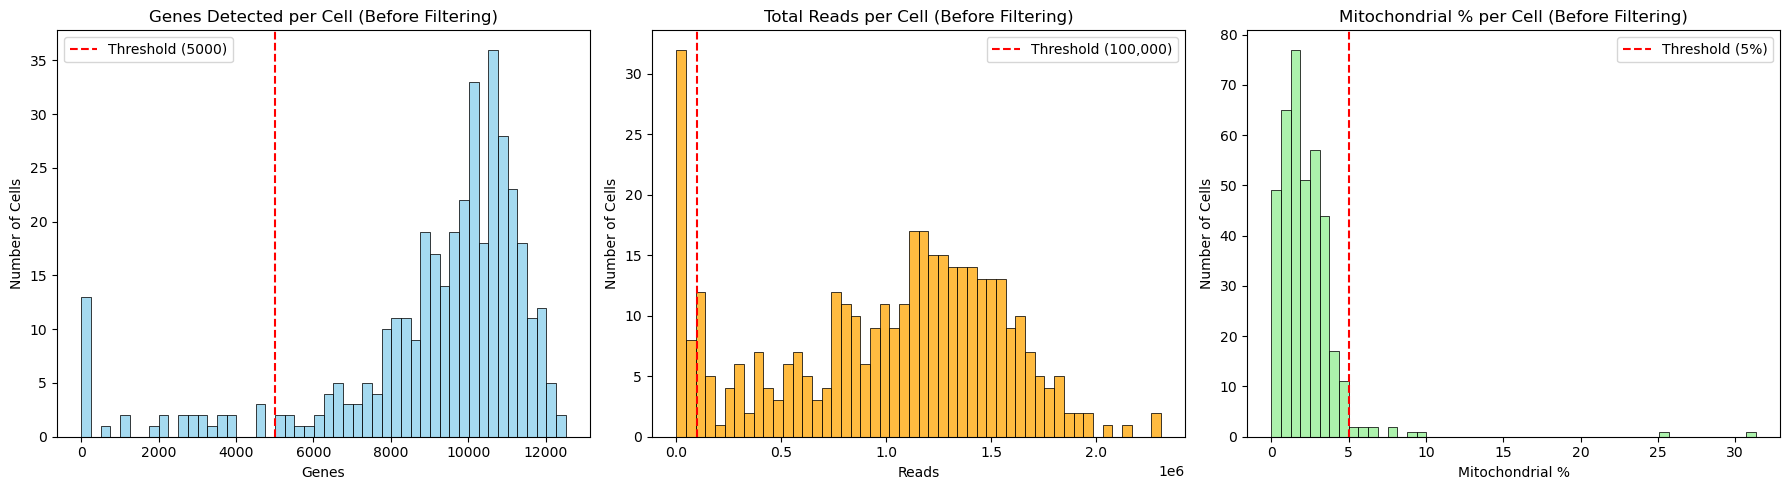

In [329]:
# ---- Calculate QC Metrics Before Filtering ----
genes_per_cell = (df_SSMCF7 > 0).sum(axis=0)
total_reads_per_cell = df_SSMCF7.sum(axis=0)

# Detect mitochondrial genes
clean_index = df_SSMCF7.index.str.replace('"', '').str.upper()
mito_genes = clean_index.str.startswith("MT")
mito_reads_per_cell = df_SSMCF7.loc[mito_genes].sum(axis=0)
mito_percent_per_cell = mito_reads_per_cell / total_reads_per_cell * 100

# ---- Plotting ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Genes per cell
sns.histplot(genes_per_cell, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title("Genes Detected per Cell (Before Filtering)")
axes[0].set_xlabel("Genes")
axes[0].set_ylabel("Number of Cells")
axes[0].axvline(5000, color='red', linestyle='--', label='Threshold (5000)')
axes[0].legend()

# Total reads per cell
sns.histplot(total_reads_per_cell, bins=50, ax=axes[1], color='orange')
axes[1].set_title("Total Reads per Cell (Before Filtering)")
axes[1].set_xlabel("Reads")
axes[1].set_ylabel("Number of Cells")
axes[1].axvline(100000, color='red', linestyle='--', label='Threshold (100,000)')
axes[1].legend()

# Mitochondrial percentage
sns.histplot(mito_percent_per_cell, bins=50, ax=axes[2], color='lightgreen')
axes[2].set_title("Mitochondrial % per Cell (Before Filtering)")
axes[2].set_xlabel("Mitochondrial %")
axes[2].set_ylabel("Number of Cells")
axes[2].axvline(5, color='red', linestyle='--', label='Threshold (5%)')
axes[2].legend()

plt.tight_layout()
plt.show()

As we can see the three thresholds seem to be good. In the first and the last case we see that just the tails are cut off without digging into the "body" of the distribution itself. In the second case we see a spike around 0 and then a decrease before an increase starts again which suggests we have removed a cluster of "bad" cells around 0 while leaving the true distribution intact. 

##### Normalization and Transformation

Now that we have finished the quality control we can move to the normalization and the transformation. It is crucial that this step is taken after we have removed the low quality cells as such "bad" cells would distort the scaling and could skew the mean and variance used in standardization. According to pmc.ncbi.nlm.nih.gov, Smart-seq and Drop-seq data will have different sequencing depths as Smart-seq typically has higher read depth per cell (full-length transcripts), while Drop-seq (UMI-based) has more cells but sparser counts. We need to normalize each to account for library size differences.  

One cell might have 1,000,000 total reads, another only 100,000.
Raw counts would:

- Bias models toward high-depth cells
- Distort comparisons
- Confound clustering/dimensionality reduction


After we have done the normalization we perform log-transform. That is because the dataset is quite sparse and also some genes are expressed with very high levels across most cells which may lead with issues down the line. For instance the highly expressed genes would dominate variance based methods like PCA. With the log transfrom we compress this range so the range of the possible expression values will become much smaller. This also improves variance stability and in general makes our gene-level distribution more model friendly. 


In [333]:
# Normalize library size per cell to a fixed total (e.g., 10,000 reads)
df_normalized_SSMCF7 = df_filtered_SSMCF7.div(df_filtered_SSMCF7.sum(axis=0), axis=1) * 1e4

#Check that all cells now sum to ~10,000
print("Column sums after normalization (should be ~10,000):")
print(df_normalized_SSMCF7.sum(axis=0).describe())

df_log_SSMCF7 = np.log1p(df_normalized_SSMCF7)

#Check values range after log
print("Range of values after befor and after log transform:")
print(df_normalized_SSMCF7.min().min(), "to", df_normalized_SSMCF7.max().max())
print(df_log_SSMCF7.min().min(), "to", df_log_SSMCF7.max().max())


Column sums after normalization (should be ~10,000):
count    3.280000e+02
mean     1.000000e+04
std      1.742276e-13
min      1.000000e+04
25%      1.000000e+04
50%      1.000000e+04
75%      1.000000e+04
max      1.000000e+04
dtype: float64
Range of values after befor and after log transform:
0.0 to 1265.5776378044795
0.0 to 7.144073768632363


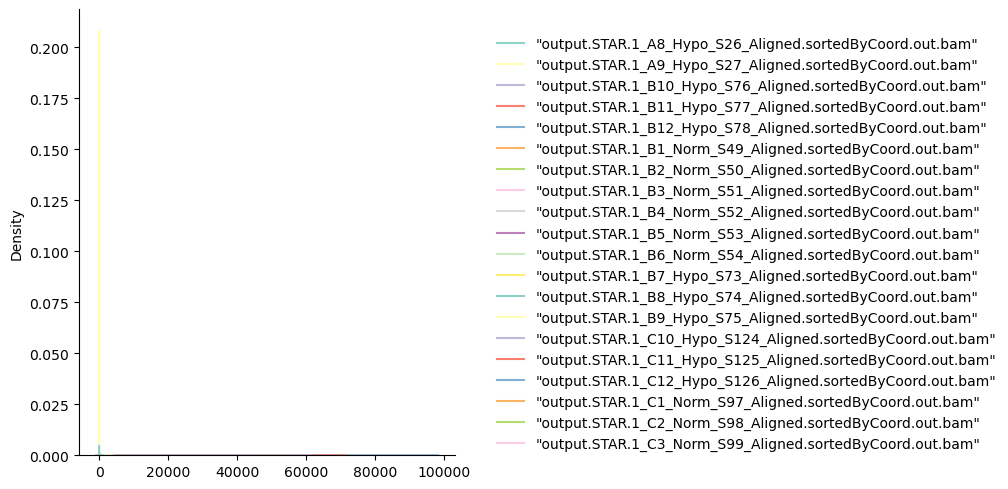

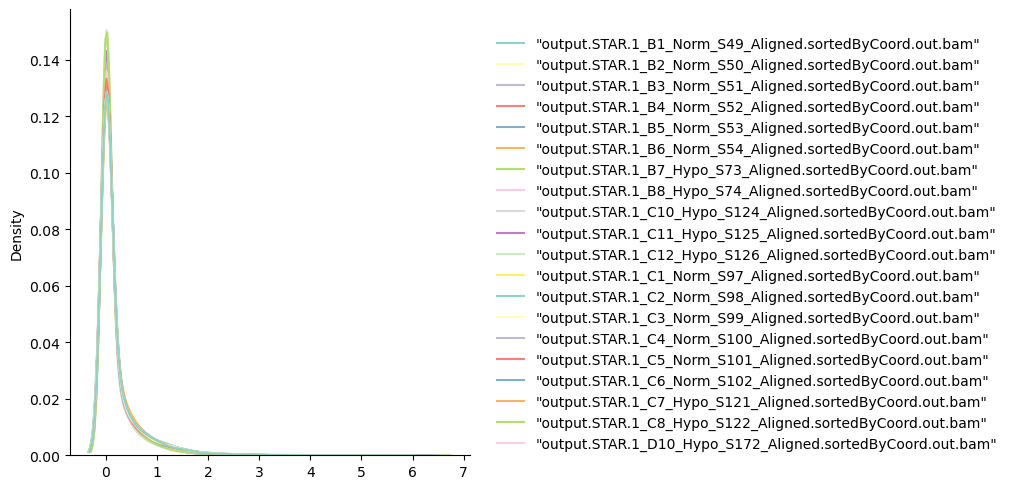

In [334]:
df_small = df_SSMCF7.iloc[:, 10:30]  #just selecting part of the samples so run time not too long
sns.displot(data=df_small,palette="Set3",kind="kde", bw_adjust=2)

df_small2 = df_log_SSMCF7.iloc[:, 10:30] 
sns.displot(data=df_small2,palette="Set3",kind="kde", bw_adjust=2)

##### Identifying High Variable Genes

Lastly we identify the high variance genes as these are the only ones that we will use during the training. The low variance genes likely do not provide and meaningful information about the underlying condition and would only introduce noise and difficulties in training. 

In [337]:
# Step 1: Compute variance for each gene
gene_variances = df_log_SSMCF7.var(axis=1)

# Step 2: Select top N genes with highest variance
top_n = 3000
top_hvgs = gene_variances.sort_values(ascending=False).head(top_n)

# Step 3: Get a new expression matrix with only those genes
df_hvg = df_log_SSMCF7.loc[top_hvgs.index]
print("Shape of the filtered DataFrame with top HVGs:", df_hvg.shape)

Shape of the filtered DataFrame with top HVGs: (3000, 328)


#### SmartSeq HCC1806 Unfiltered

In [339]:
#Initial dataframe exploration

df_SSHCC1806 = pd.read_csv("SmartSeq/HCC1806/HCC1806_SmartS_Unfiltered_Data.txt",delimiter=r"\ ",engine='python',index_col=0)
print("Dataframe dimensions:", np.shape(df_SSHCC1806))
df_SSHCC1806.head(5)

Dataframe dimensions: (23396, 243)


,"""output.STAR.PCRPlate1A10_Normoxia_S123_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A12_Normoxia_S26_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A4_Hypoxia_S8_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A5_Hypoxia_S108_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A6_Hypoxia_S11_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A7_Normoxia_S113_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1A8_Normoxia_S119_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam"""
"""WASH7P""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""CICP27""",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""DDX11L17""",0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"""WASH9P""",0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
"""OR4F29""",2,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The next crucial step in our analysis is to check for duplicates. They could result in double counting and skew the database in ways that do not accurately represent the true nature of the data. We check for duplicate cell names and gene names which would suggest an initial issue with our dataset that we need to fix. Again, we get pretty much the same result as in the Smartseq MCF7 case so our observations apply here as well. 

In [341]:
# CHECKING FOR DUPLICATES

# Check for duplicate cell names
duplicates_in_cells_SSHCC1806 = df_SSHCC1806.index.duplicated().sum()
print(f"Duplicate cell names: {duplicates_in_cells_SSHCC1806}")

# Check for duplicate gene names
duplicates_in_genes_SSHCC1806 = df_SSHCC1806.columns.duplicated().sum()
print(f"Duplicate gene names: {duplicates_in_genes_SSHCC1806}")

# Check for duplicate cell profiles
duplicate_gene_profiles = df_SSHCC1806.T.duplicated().sum()
print("Duplicate gene profiles:", duplicate_gene_profiles)

# Check for duplicate gene profiles
duplicate_gene_profiles = df_SSHCC1806.duplicated().sum()
print("Duplicate gene profiles:", duplicate_gene_profiles)

#Check for missing values
has_nulls_SSHCC1806 = df_SSHCC1806.T.isnull().values.any()
print(f"Missing values:", has_nulls_SSHCC1806)

Duplicate cell names: 0
Duplicate gene names: 0
Duplicate gene profiles: 0
Duplicate gene profiles: 54
Missing values: False


##### Quality Control

After that, we can perform some quality control on the cells. What we can do is to check the total read counts of the genes for each cell and discard cells under a certain threshold. According to bioconductor.org a suitable threshold would be 100 000 total reads per cell. Any lower than that and we risk including damaged cells in our database and analysis which could lead to additional noise, and obscuring the actual dependencies we are trying to find. 

In [344]:
total_reads_per_cell_SSHCC1806 = df_SSHCC1806.sum(axis=0)

low_quality_cells_SSHCC1806 = (total_reads_per_cell_SSHCC1806 < 100000).sum()

print(f"Number of cells with total reads < 100,000: {low_quality_cells_SSHCC1806}")

Number of cells with total reads < 100,000: 9


Additionally we can also remove cells that express less than a certain amount of genes, as this could indicate that the cell is damaged. According to bioconductor.org a suitable cut-off would be around 5000. 

In [346]:
# Set your threshold
N = 5000  # example threshold

# Count how many genes are expressed (non-zero) in each cell
genes_per_cell_SSHCC1806 = (df_SSHCC1806 > 0).sum(axis=0)

# Count how many cells have fewer than N expressed genes
low_gene_cells_SSHCC1806 = (genes_per_cell_SSHCC1806 < N).sum()

print(f"Number of cells with fewer than {N} genes expressed: {low_gene_cells_SSHCC1806}")

Number of cells with fewer than 5000 genes expressed: 9


Lastly, we look at the cells with high mitochondrial percentage. Again from the same source we filter out cells with mitochondrial percentage of over 10% as they are likely to be damaged. (i.e. cells in which over 10% of the reads come from mitochondrial genes are discarded)

In [348]:
mito_genes_SSHCC1806 = df_SSHCC1806.index.str.replace('"', '').str.upper().str.startswith("MT")
mito_reads_SSHCC1806 = df_SSHCC1806.loc[mito_genes_SSHCC1806].sum(axis=0)
total_reads_SSHCC1806 = df_SSHCC1806.sum(axis=0)

mito_percent_SSHCC1806 = mito_reads_SSHCC1806 / total_reads_SSHCC1806 * 100

threshold = 5

num_high_mito_cells_SSHCC1806 = (mito_percent_SSHCC1806 >= threshold).sum()
print(f"Number of cells with > {threshold}% mitochondrial reads: {num_high_mito_cells_SSHCC1806}")

Number of cells with > 5% mitochondrial reads: 6


Now we remove the cells that are likely to be damaged. 

In [350]:
# Build a boolean mask: keep only cells that meet both thresholds
high_quality_cells_SSHCC1806 = (total_reads_per_cell_SSHCC1806 >= 100000) & (genes_per_cell_SSHCC1806 >= 5000) & (mito_percent_SSHCC1806 < 5)

# Filter the DataFrame to keep only those cells (columns)
df_filtered_SSHCC1806 = df_SSHCC1806.loc[:, high_quality_cells_SSHCC1806]

print(f"Original number of cells: {df_SSHCC1806.shape[1]}")
print(f"Number of cells kept after filtering: {df_filtered_SSHCC1806.shape[1]}")

Original number of cells: 243
Number of cells kept after filtering: 230


What we do now is to double check that our thresholds are reasonable. For that we will make some plots that will help us with visualizing the numbers. 

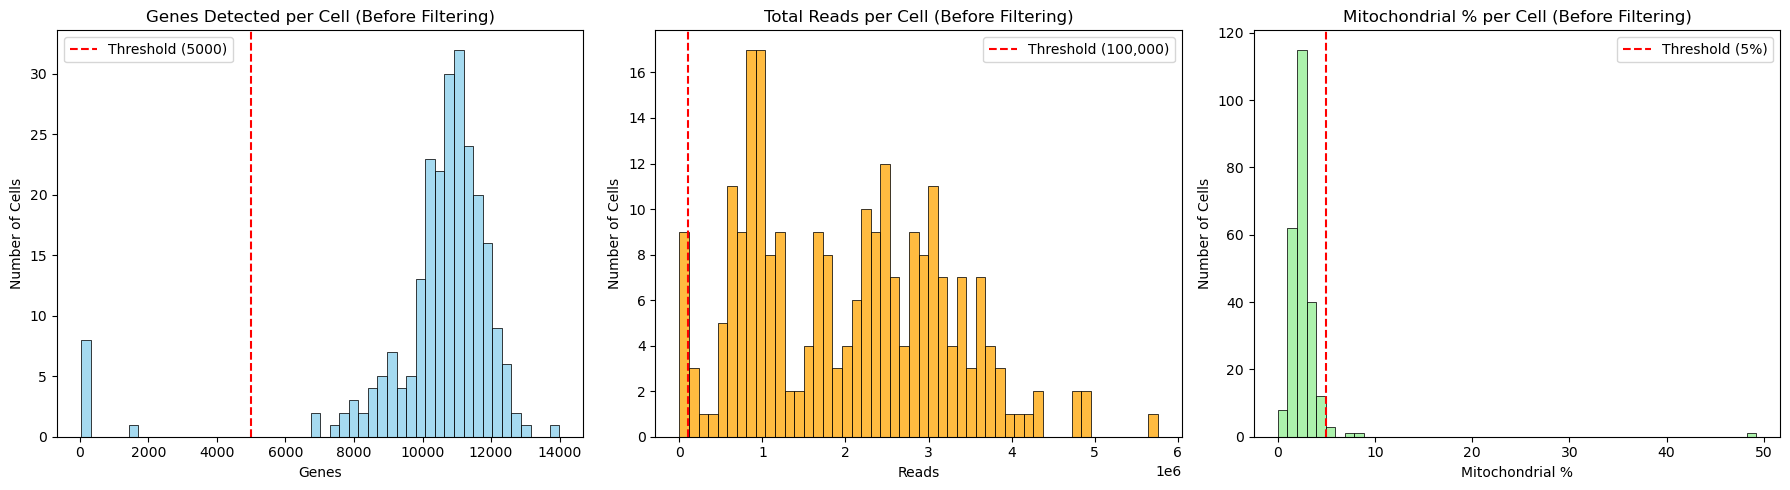

In [352]:
# ---- Calculate QC Metrics Before Filtering ----
genes_per_cell_SSHCC1806 = (df_SSHCC1806 > 0).sum(axis=0)
total_reads_per_cell_SSHCC1806 = df_SSHCC1806.sum(axis=0)

# Detect mitochondrial genes
clean_index_SSHCC1806 = df_SSHCC1806.index.str.replace('"', '').str.upper()
mito_genes_SSHCC1806 = clean_index_SSHCC1806.str.startswith("MT")
mito_reads_per_cell_SSHCC1806 = df_SSHCC1806.loc[mito_genes_SSHCC1806].sum(axis=0)
mito_percent_per_cell_SSHCC1806 = mito_reads_per_cell_SSHCC1806 / total_reads_per_cell_SSHCC1806 * 100

# ---- Plotting ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Genes per cell
sns.histplot(genes_per_cell_SSHCC1806, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title("Genes Detected per Cell (Before Filtering)")
axes[0].set_xlabel("Genes")
axes[0].set_ylabel("Number of Cells")
axes[0].axvline(5000, color='red', linestyle='--', label='Threshold (5000)')
axes[0].legend()

# Total reads per cell
sns.histplot(total_reads_per_cell_SSHCC1806, bins=50, ax=axes[1], color='orange')
axes[1].set_title("Total Reads per Cell (Before Filtering)")
axes[1].set_xlabel("Reads")
axes[1].set_ylabel("Number of Cells")
axes[1].axvline(100000, color='red', linestyle='--', label='Threshold (100,000)')
axes[1].legend()

# Mitochondrial percentage
sns.histplot(mito_percent_per_cell_SSHCC1806, bins=50, ax=axes[2], color='lightgreen')
axes[2].set_title("Mitochondrial % per Cell (Before Filtering)")
axes[2].set_xlabel("Mitochondrial %")
axes[2].set_ylabel("Number of Cells")
axes[2].axvline(5, color='red', linestyle='--', label='Threshold (5%)')
axes[2].legend()

plt.tight_layout()
plt.show()

As we can see the three thresholds seem to to good. Again as in MCF7 we see that in the first and the last case just the tails are cut off without digging into the "body" of the distribution itself. In the second case however we don't see as large of a spike around 0 which suggests that more cells are of higher quallity. 

##### Normalization and Transformation

Now that we have finished the quality control we can move to the normalization and the transformation. It is crucial that this step is taken after we have removed the low quality cells as such "bad" cells would distort the scaling and could skew the mean and variance used in standardization. 

One cell might have 1,000,000 total reads, another only 100,000. Such discrepancies can hinder the performance of models and give poor results and could: 

- Bias models toward high-depth cells
- Distort comparisons
- Confound clustering/dimensionality reduction


After we have done the normalization we perform log-transform. That is because the dataset is quite sparse and also some genes are expressed with very high levels across most cells which may lead with issues down the line. For instance the highly expressed genes would dominate variance based methods like PCA. With the log transform we compress this range so the range of the possible expression values will become much smaller. This also improves variance stability and in general makes our gene-level distribution more model friendly. 


In [356]:
# Normalize library size per cell to a fixed total (e.g., 10,000 reads)
df_normalized_SSHCC1806 = df_filtered_SSHCC1806.div(df_filtered_SSHCC1806.sum(axis=0), axis=1) * 1e4

#Check that all cells now sum to ~10,000
print("Column sums after normalization (should be ~10,000):")
print(df_normalized_SSHCC1806.sum(axis=0).describe())

df_log_SSHCC1806 = np.log1p(df_normalized_SSHCC1806)

#Check values range after log
print("Range of values after befor and after log transform:")
print(df_normalized_SSHCC1806.min().min(), "to", df_normalized_SSHCC1806.max().max())
print(df_log_SSHCC1806.min().min(), "to", df_log_SSHCC1806.max().max())

Column sums after normalization (should be ~10,000):
count    2.300000e+02
mean     1.000000e+04
std      1.699916e-13
min      1.000000e+04
25%      1.000000e+04
50%      1.000000e+04
75%      1.000000e+04
max      1.000000e+04
dtype: float64
Range of values after befor and after log transform:
0.0 to 521.7027854205954
0.0 to 6.259013014613412


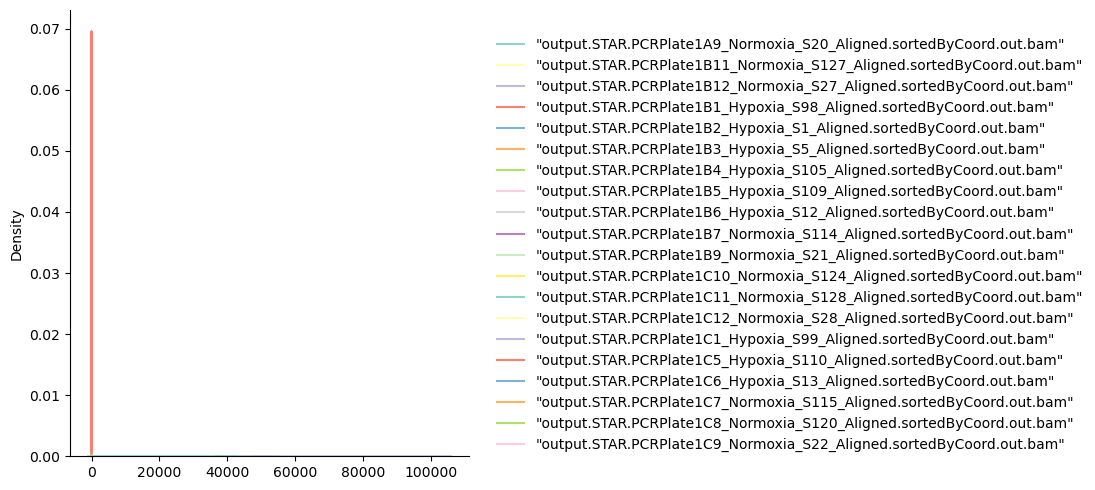

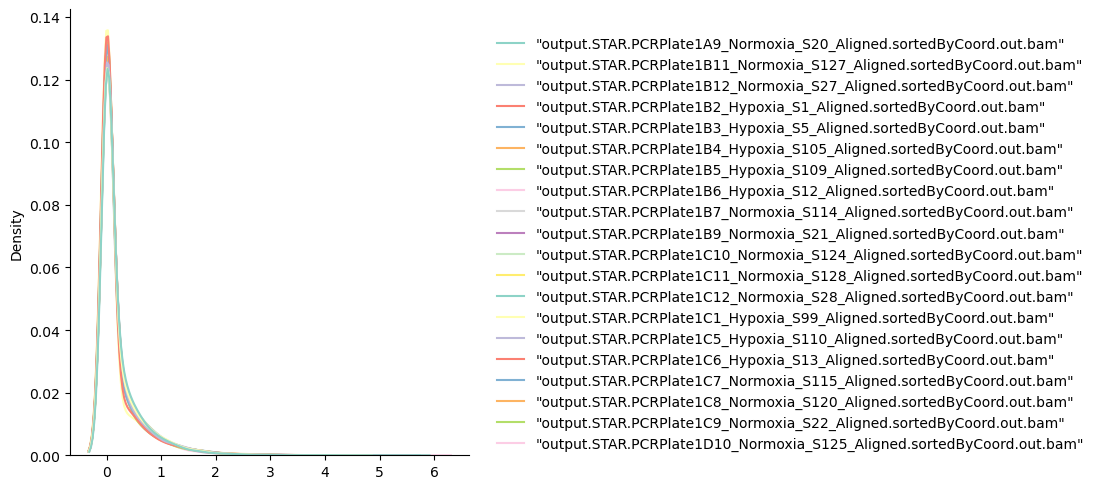

In [357]:
df_small_SSHCC1806 = df_SSHCC1806.iloc[:, 10:30]  #just selecting part of the samples so run time not too long
sns.displot(data=df_small_SSHCC1806,palette="Set3",kind="kde", bw_adjust=2)

df_small2_SSHCC1806 = df_log_SSHCC1806.iloc[:, 10:30] 
sns.displot(data=df_small2_SSHCC1806,palette="Set3",kind="kde", bw_adjust=2)

##### Identifying High Variable Genes

In [359]:
# Step 1: Compute variance for each gene
gene_variances_SSHCC1806 = df_log_SSHCC1806.var(axis=1)

# Step 2: Select top N genes with highest variance
top_n = 3000
top_hvgs_SSHCC1806 = gene_variances_SSHCC1806.sort_values(ascending=False).head(top_n)

# Step 3: Get a new expression matrix with only those genes
df_hvg_SSHCC1806 = df_log_SSHCC1806.loc[top_hvgs_SSHCC1806.index]
print("Shape of the filtered DataFrame with top HVGs:", df_hvg_SSHCC1806.shape)

Shape of the filtered DataFrame with top HVGs: (3000, 230)


## DropSeq

#### DropSeq MCF7 Filtered

Now, we are going to remove all the cells that have less than 50 genes. These cells are likely damaged and of no interest.

In [363]:
different_genes_per_cell = (df_DSMCF7 > 0).sum(axis=0)
cells_that_have_below_50_genes = different_genes_per_cell[different_genes_per_cell < 50].index
df_DSMCF7.drop(columns=cells_that_have_below_50_genes, inplace=True)

Following, we can also remove the cells in which there are less than 70 genes present in total.

In [365]:
number_of_total_genes = df_DSMCF7.sum(axis=0)
below_70_genes_in_total = number_of_total_genes[number_of_total_genes < 70].index
df_DSMCF7.drop(columns=below_70_genes_in_total, inplace=True)

In [366]:
df_DSMCF7.shape

(3000, 17357)

For the last step of the preprocessing of the columns, we need to find what is the percentage of mitochondria genes present in each cell. For the cells with a higher percentage than 10%, we will remove them.

In [368]:
df_DSMCF7.index = df_DSMCF7.index.str.strip('"')
mt_genes = df_DSMCF7.index.str.startswith("MT-")
pct_mito = df_DSMCF7[mt_genes].sum(axis=0) / df_DSMCF7.sum(axis=0)
to_drop = pct_mito[pct_mito > 0.1].index
df_DSMCF7.drop(columns=to_drop, inplace=True)

In [369]:
genes_to_keep = (df_DSMCF7 > 0).sum(axis=1) > 5
df_DSMCF7 = df_DSMCF7[genes_to_keep]

Here, we apply the log transformation to reduce the sparsity in our dataset.

In [371]:
df_DSMCF7 = np.log1p(df_DSMCF7)

In this section, we want to look at the least popular genes in our dataset and keep only the ones that appear more than 50 times.

In [373]:
df_DSMCF7 = df_DSMCF7[df_DSMCF7.sum(axis=1) > 50]

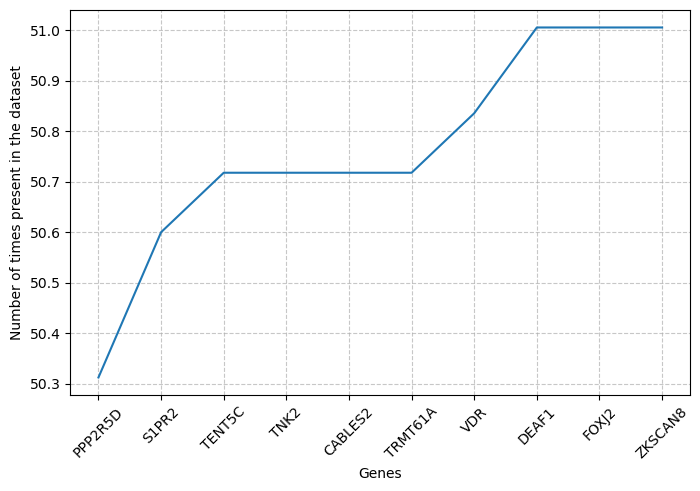

In [374]:
plt.figure(figsize=(8, 5))
most_frequent_genes = df_DSMCF7.sum(axis=1).sort_values(ascending=True).head(10)
plt.plot(most_frequent_genes)
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Genes")
plt.ylabel("Number of times present in the dataset")
plt.show()

As for the last step, we aim at keeping all the genes that have a variance of 0.1 or higher.

In [376]:
df_DSMCF7 = df_DSMCF7[df_DSMCF7.var(axis=1) > 0.01]

#### DropSeq HCC1806 Filtered

Now, we are going to remove all the cells that have less than 50 genes.

In [379]:
different_genes_per_cell = (df_DSHCC1806 > 0).sum(axis=0)

In [380]:
cells_that_have_below_50_genes = different_genes_per_cell[different_genes_per_cell < 50].index
df_DSHCC1806.drop(columns=cells_that_have_below_50_genes, inplace=True)

Following, we can also remove the cells in which there are less than 70 genes present in total.

In [382]:
number_of_total_genes = df_DSHCC1806.sum(axis=0)
below_70_genes_in_total = number_of_total_genes[number_of_total_genes < 70].index
df_DSHCC1806.drop(columns=below_70_genes_in_total, inplace=True)

For the last step of the preprocessing of the columns, we need to find what the percentage of mitochondria genes present in each cell is. Cells with a mitochondrial gene percentage higher than 10% will be removed.

In [384]:
df_DSHCC1806.index = df_DSHCC1806.index.str.strip('"')
mt_genes = df_DSHCC1806.index.str.startswith("MT-")
pct_mito = df_DSHCC1806[mt_genes].sum(axis=0) / df_DSHCC1806.sum(axis=0)
to_drop = pct_mito[pct_mito > 0.1].index
df_DSHCC1806.drop(columns=to_drop, inplace=True)

In [385]:
genes_to_keep = (df_DSHCC1806 > 0).sum(axis=1) > 5
df_DSHCC1806 = df_DSHCC1806[genes_to_keep]

Here, we apply the log transformation to reduce the sparsity in our dataset.

In [387]:
df_DSHCC1806 = np.log1p(df_DSHCC1806)

In this section, we want to look at the least popular genes in our dataset and keep only the ones that appear more than 50 times.

In [389]:
df_DSHCC1806 = df_DSHCC1806[df_DSHCC1806.sum(axis=1) > 50]

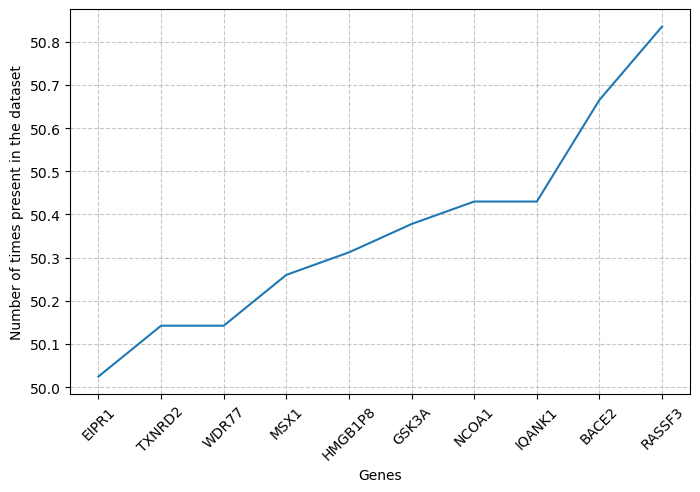

In [390]:
plt.figure(figsize=(8, 5))
most_frequent_genes = df_DSHCC1806.sum(axis=1).sort_values(ascending=True).head(10)
plt.plot(most_frequent_genes)
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Genes")
plt.ylabel("Number of times present in the dataset")
plt.show()

As for the last step, we aim at keeping all the genes that have a variance of 0.1 or higher.

In [392]:
df_DSHCC1806 = df_DSHCC1806[df_DSHCC1806.var(axis=1) > 0.01]